# ShareGPT Dataset Exploration

In [5]:
import json
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from transformers import AutoTokenizer

from kvswitch.eval.workload import load_sharegpt_conversations

sns.set_theme(style="whitegrid")
matplotlib.rcParams.update(
    {
        "font.size": 10,
        "axes.labelsize": 11,
        "axes.titlesize": 12,
        "legend.fontsize": 7,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "figure.dpi": 300,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
    }
)

In [2]:
DATA_PATH = Path("../data/ShareGPT_V3_unfiltered_cleaned_split.json")
MODEL = "meta-llama/Llama-3.2-3B-Instruct"

pairs = load_sharegpt_conversations(DATA_PATH)
tokenizer = AutoTokenizer.from_pretrained(MODEL)

print(f"Total conversations: {len(pairs)}")
print(f"Conversations with GPT reply: {sum(1 for _, r in pairs if r is not None)}")

Total conversations: 92812
Conversations with GPT reply: 92729


In [ ]:
prompt_lengths = []
output_lengths = []

for human_text, gpt_reply in pairs:
    prompt_ids = tokenizer.encode(human_text)
    prompt_lengths.append(len(prompt_ids))
    if gpt_reply:
        output_ids = tokenizer.encode(gpt_reply)
        output_lengths.append(len(output_ids))
    else:
        output_lengths.append(0)

prompt_lengths = np.array(prompt_lengths)
output_lengths = np.array(output_lengths)

Token indices sequence length is longer than the specified maximum sequence length for this model (161272 > 131072). Running this sequence through the model will result in indexing errors


                              Prompt     Output
                    Count      92812      92729
              Mean tokens      176.3      302.7
            Median tokens       24.0      273.0
               Std tokens      875.8      219.9
               Min tokens          2          2
               Max tokens     161272      22268
               P25 tokens         12        143
               P75 tokens         79        419
               P95 tokens        958        745
               P99 tokens       2474        771


In [15]:
print(f"{'':>25s} {'Prompt':>10s} {'Output':>10s}")
print(f"{'Count':>25s} {len(prompt_lengths):>10d} {np.sum(output_lengths > 0):>10d}")
print(f"{'Mean tokens':>25s} {prompt_lengths.mean():>10.1f} {output_lengths[output_lengths > 0].mean():>10.1f}")
print(f"{'Median tokens':>25s} {np.median(prompt_lengths):>10.1f} {np.median(output_lengths[output_lengths > 0]):>10.1f}")
print(f"{'Std tokens':>25s} {prompt_lengths.std():>10.1f} {output_lengths[output_lengths > 0].std():>10.1f}")
print(f"{'Min tokens':>25s} {prompt_lengths.min():>10d} {output_lengths[output_lengths > 0].min():>10d}")
print(f"{'Max tokens':>25s} {prompt_lengths.max():>10d} {output_lengths[output_lengths > 0].max():>10d}")
print(f"{'P25 tokens':>25s} {np.percentile(prompt_lengths, 25):>10.0f} {np.percentile(output_lengths[output_lengths > 0], 25):>10.0f}")
print(f"{'P75 tokens':>25s} {np.percentile(prompt_lengths, 75):>10.0f} {np.percentile(output_lengths[output_lengths > 0], 75):>10.0f}")
print(f"{'P95 tokens':>25s} {np.percentile(prompt_lengths, 95):>10.0f} {np.percentile(output_lengths[output_lengths > 0], 95):>10.0f}")
print(f"{'P99 tokens':>25s} {np.percentile(prompt_lengths, 99):>10.0f} {np.percentile(output_lengths[output_lengths > 0], 99):>10.0f}")

                              Prompt     Output
                    Count      92812      92729
              Mean tokens      176.3      302.7
            Median tokens       24.0      273.0
               Std tokens      875.8      219.9
               Min tokens          2          2
               Max tokens     161272      22268
               P25 tokens         12        143
               P75 tokens         79        419
               P95 tokens        958        745
               P99 tokens       2474        771


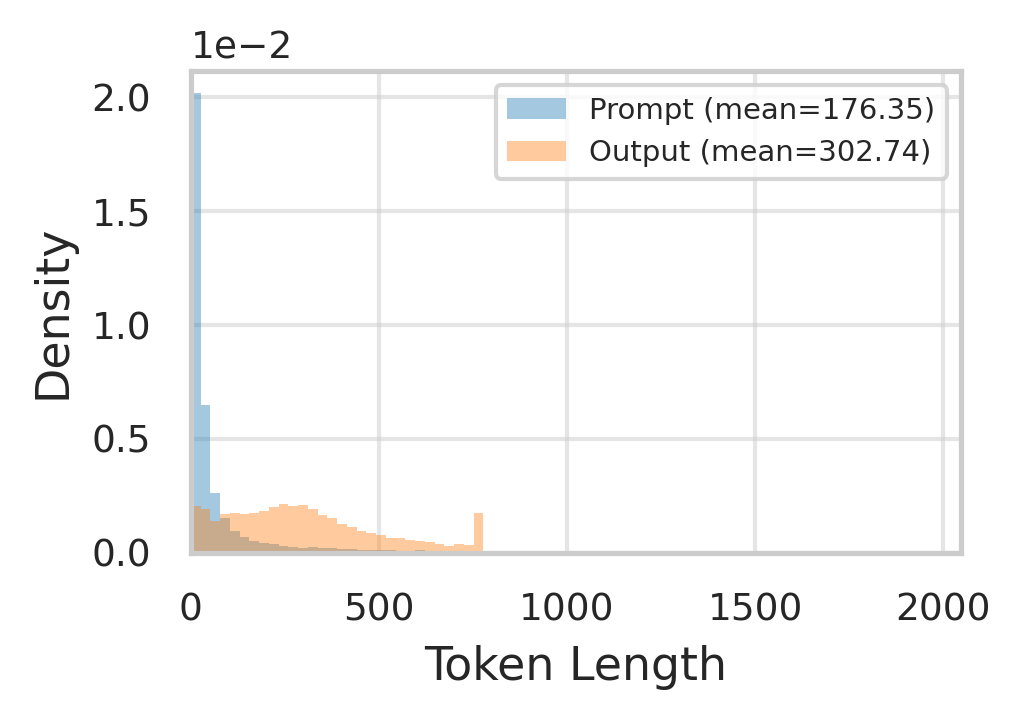

Trimmed from plot: 1438 prompts, 4 outputs (>2048 tokens)


In [14]:
CUTOFF = 2048  # tokens

fig, ax = plt.subplots(figsize=(3.5, 2.5))

prompt_mean = prompt_lengths.mean()
output_mean = output_lengths[output_lengths > 0].mean()

prompt_cut = prompt_lengths[prompt_lengths <= CUTOFF]
output_cut = output_lengths[(output_lengths > 0) & (output_lengths <= CUTOFF)]
bins = np.linspace(0, CUTOFF, 80)

sns.histplot(prompt_cut, bins=bins, ax=ax, color="tab:blue", alpha=0.4,
             label=f"Prompt (mean={prompt_mean:.2f})", edgecolor="none", stat="density")
sns.histplot(output_cut, bins=bins, ax=ax, color="tab:orange", alpha=0.4,
             label=f"Output (mean={output_mean:.2f})", edgecolor="none", stat="density")

ax.ticklabel_format(axis="y", style="sci", scilimits=(0,0))
ax.set_xlabel("Token Length")
ax.set_ylabel("Density")
ax.set_xlim(0, CUTOFF)
ax.legend()
ax.grid(True, alpha=0.5)
fig.tight_layout()
plt.show()

n_prompt_trimmed = int(np.sum(prompt_lengths > CUTOFF))
n_output_trimmed = int(np.sum((output_lengths > 0) & (output_lengths > CUTOFF)))
print(f"Trimmed from plot: {n_prompt_trimmed} prompts, {n_output_trimmed} outputs (>{CUTOFF} tokens)")